### Phase 2 - Organization and desgin

In [344]:
# Importar librerías 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

In [231]:
# Importar archivo csv
df = pd.read_csv('Appendix 1 - Database.csv', encoding="latin1")

In [232]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [234]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [235]:
# Identificar registros negativos y ceros

print("Registros con 'Quantity' <= 0", df[df['Quantity'] <= 0].shape[0])
print("Registros con 'UnitPrice' <= 0:", df[df['UnitPrice'] <= 0].shape[0])

Registros con 'Quantity' <= 0 10624
Registros con 'UnitPrice' <= 0: 2517


In [236]:
"""
    En los modelo de segmentación de clientes, lo más adecuado es eliminar las devoluciones y 
    los precios en 0 para no sesgar el gasto real.
"""

# Eliminar cantidades negativas, precios unitarios de 0 (devoluciones, ajustes del stock o regalos)
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy() 

# Eliminar valores faltantes en la columna CustomerID  (necesario para clustering)
df_clean = df_clean.dropna(subset=['CustomerID'])

# Convertir tipos de datos
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['CustomerID'] = df_clean['CustomerID'].astype(float).astype(int).astype(str)

# Eliminar duplicados
df_clean = df_clean.drop_duplicates()

# Calcular TotalPrice = Quantity * UnitPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Limpieza finalizada. Filas finales: {df_clean.shape[0]}")

Limpieza finalizada. Filas finales: 392692


In [237]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


### Paso 1: Transforme la base de datos en un conjunto de datos a nivel de cliente, donde cada fila corresponde a la información de un único cliente, incluyendo las siguientes variables:

• ID de cliente (identificador único)  
• Fecha de la compra más reciente  
• Antigüedad (tiempo transcurrido desde la última compra)  
• Frecuencia (número de compras en un período definido)  
• Total, de compras (importe total gastado)  
• País (origen de las compras)  
• Compra mínima y compra promedio  

Realice un análisis exploratorio de datos (EDA) en esta tabla a nivel de cliente: incluya estadísticas descriptivas y gráficos de apoyo, y escriba una breve interpretación con sus propias palabras.

In [238]:
# Fecha de referencia para el cálculo de antigüedad
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Agrupamos por CustomerID y Country
df_clientes = df_clean.groupby(['CustomerID', 'Country']).agg({
    'InvoiceDate': [
        'max',                                     # Fecha compra más reciente
        lambda x: (snapshot_date - x.max()).days   # Antigüedad (Recencia)
    ],
    'InvoiceNo': 'nunique',                        # Frecuencia (compras únicas)
    'TotalPrice': [
        'sum',                                     # Importe total gastado
        'min',                                     # Compra mínima
        'mean'                                     # Compra promedio
    ]
}).reset_index()

# Renombrar columnas para que sean claras
df_clientes.columns = [
    'CustomerID', 'Country', 'FechaReciente', 'Recency', 
    'Frequency', 'TotalPurchases', 'MinPurchase', 'AvgPurchase'
]

print("Tabla a nivel de cliente generada:")
print(df_clientes.head())

Tabla a nivel de cliente generada:
  CustomerID         Country       FechaReciente  Recency  Frequency  \
0      12346  United Kingdom 2011-01-18 10:01:00      326          1   
1      12347         Iceland 2011-12-07 15:52:00        2          7   
2      12348         Finland 2011-09-25 13:13:00       75          4   
3      12349           Italy 2011-11-21 09:51:00       19          1   
4      12350          Norway 2011-02-02 16:01:00      310          1   

   TotalPurchases  MinPurchase   AvgPurchase  
0        77183.60     77183.60  77183.600000  
1         4310.00         5.04     23.681319  
2         1797.24        13.20     57.975484  
3         1757.55         6.64     24.076027  
4          334.40         8.50     19.670588  


In [239]:
# Estadísticas descriptivas de las variables numéricas
desc = df_clientes[['Recency', 'Frequency', 'TotalPurchases', 'MinPurchase', 'AvgPurchase']].describe().round(2)
print(desc)

       Recency  Frequency  TotalPurchases  MinPurchase  AvgPurchase
count  4346.00    4346.00         4346.00      4346.00      4346.00
mean     92.74       4.26         2044.92        31.88        68.36
std     100.12       7.69         8977.09      1174.87      1466.57
min       1.00       1.00            3.75         0.00         2.14
25%      18.00       1.00          306.59         0.95        12.40
50%      51.00       2.00          666.88         5.04        17.78
75%     143.00       5.00         1656.54         9.95        24.88
max     374.00     209.00       280206.02     77183.60     77183.60


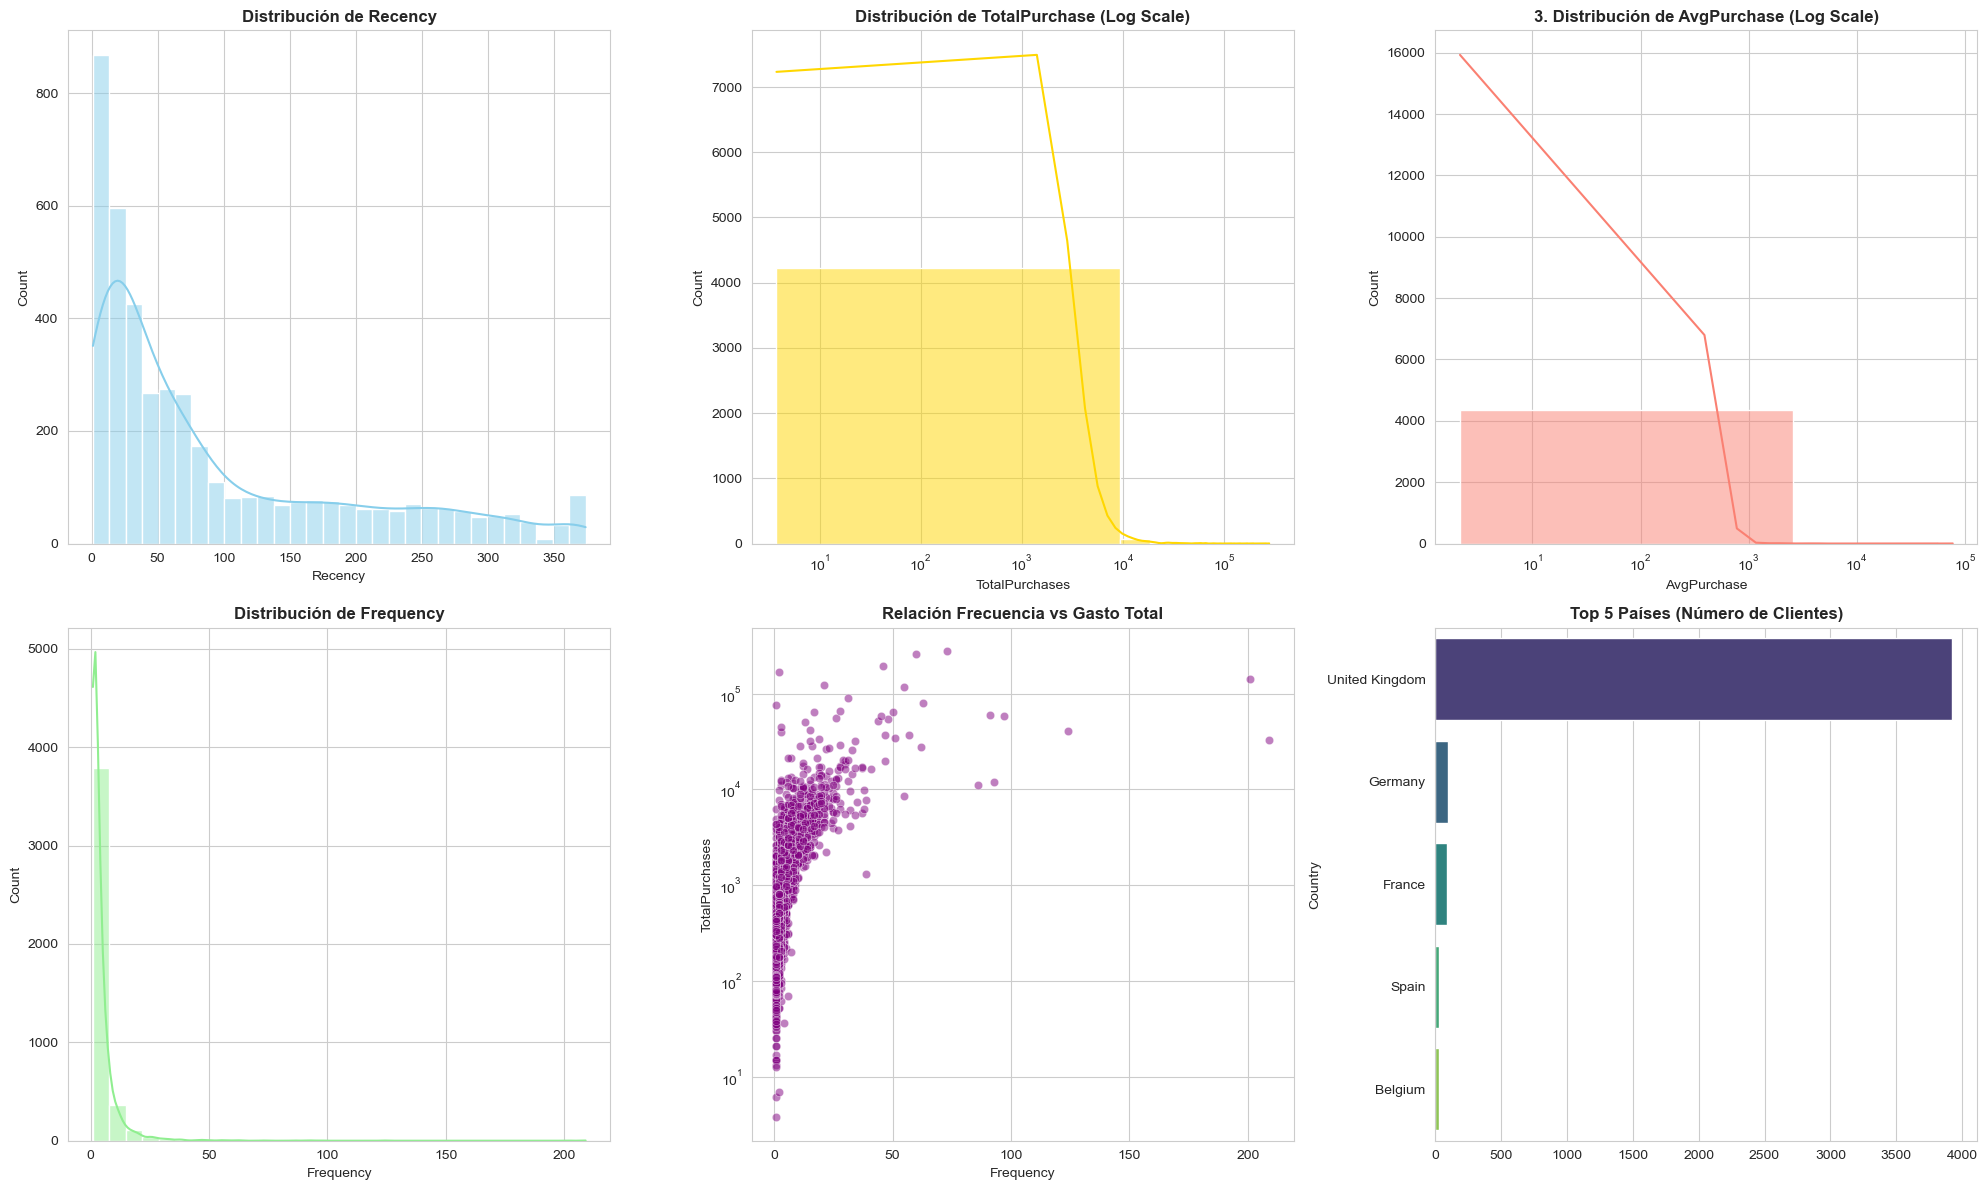

In [240]:
#  Gráficas EDA

# Configuración de estilo
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Histograma Recency
sns.histplot(cust['Recency'], bins=30, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Recency', fontweight="bold")

# 2. Histograma TotalPurchase
sns.histplot(cust['TotalPurchases'], bins=30, kde=True, color='gold', ax=axes[0, 1])
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Distribución de TotalPurchase (Log Scale)', fontweight="bold")

# 3. Histograma AvgPurchase
sns.histplot(cust['AvgPurchase'], bins=30, kde=True, color='salmon', ax=axes[0, 2])
axes[0, 2].set_xscale('log')
axes[0, 2].set_title('3. Distribución de AvgPurchase (Log Scale)', fontweight="bold")

# 4. Histograma Frequency
sns.histplot(cust['Frequency'], bins=30, kde=True, color='lightgreen', ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Frequency', fontweight="bold")

# 5. Dispersión Frecuencia vs Gasto
sns.scatterplot(data=cust, x='Frequency', y='TotalPurchases', alpha=0.5, color='purple', ax=axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Relación Frecuencia vs Gasto Total', fontweight="bold")

# 6. Top 5 Países
top_5_countries = cust['Country'].value_counts().head(5)
sns.barplot(x=top_5_countries.values, y=top_5_countries.index, palette='viridis', ax=axes[1, 2])
axes[1, 2].set_title('Top 5 Países (Número de Clientes)', fontweight="bold")

plt.tight_layout()
plt.savefig("Paso1_EDA.png", dpi=130, bbox_inches="tight")
plt.show();

### Paso 2: Agrupamiento K-means de clientes:
• Estandarice/escale las variables que agrupará (justifique su elección de variables).  
• Seleccione un valor inicial de k según su propio criterio analítico; ejecute K-means e informe las variables, el escalado y el valor inicial de k con su justificación.  
• Ejecute K-means y documente: las variables utilizadas, la elección del escalado, el valor inicial de k y su justificación.  
• Luego, evalúe k y decida si mantenerlo o ajustarlo. Explique su decisión.

In [241]:
# Selección de variables
X = cust[['Recency', 'Frequency', 'TotalPurchases']]

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Creamos un DataFrame para ver los datos escalados
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Datos escalados (Primeras 5 filas):")
print(X_scaled_df.head())

Datos escalados (Primeras 5 filas):
    Recency  Frequency  TotalPurchases
0  2.330116  -0.424446        8.371016
1 -0.906469   0.355750        0.252347
2 -0.177238  -0.034348       -0.027593
3 -0.736648  -0.424446       -0.032015
4  2.170285  -0.424446       -0.190564


In [242]:
# Definición del modelo con k=4
k_inicial = 4
kmeans = KMeans(n_clusters=k_inicial, init='k-means++', random_state=42, n_init=10)
cust['Cluster_Inicial'] = kmeans.fit_predict(X_scaled)

print(f"Modelo ejecutado con k={k_inicial}")

Modelo ejecutado con k=4


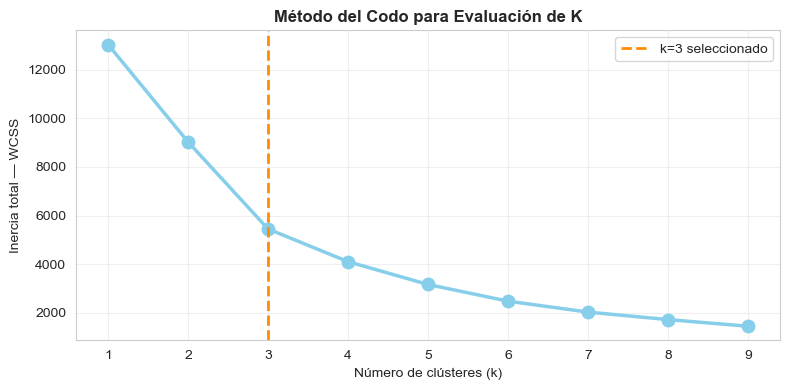


 Decisión: k=3
   El punto de quiebre más notorio está en k=3
   A partir de k=4 o k=5 la línea se vuelve más plana. 
   Agregar más grupos no aporta una mejora significativa en la segmentación.


In [243]:
# Evaluación de k (Método del Codo)
inercia = []
K_range = range(1, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inercia.append(model.inertia_)

# Graficar Método del Codo
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inercia, "o-", color='skyblue', linewidth=2.5, markersize=9)
ax.axvline(x=3, color='darkorange', linestyle="--", linewidth=2, label="k=3 seleccionado")

ax.set_title("Método del Codo para Evaluación de K", fontweight='bold', fontsize=12)
ax.set_xlabel("Número de clústeres (k)", fontsize=10)
ax.set_ylabel("Inercia total — WCSS", fontsize=10)
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_xticks(list(K_range))
plt.tight_layout(); plt.show()

print("\n Decisión: k=3")
print("   El punto de quiebre más notorio está en k=3")
print("   A partir de k=4 o k=5 la línea se vuelve más plana. ")
print("   Agregar más grupos no aporta una mejora significativa en la segmentación.")

In [244]:
# Definir y ajustar el modelo final con k=3
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
cust['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Ver cuántos clientes hay en cada grupo
print("Cantidad de clientes por cluster:")
print(cust['Cluster'].value_counts())

# Analizar los centros de los grupos (Promedios por cluster)
resumen_clusters = cust.groupby('Cluster')[['Recency', 'Frequency', 'TotalPurchases']].mean()
print("\nPerfil promedio de cada cluster:")
print(resumen_clusters)

Cantidad de clientes por cluster:
Cluster
0    3232
1    1088
2      26
Name: count, dtype: int64

Perfil promedio de cada cluster:
            Recency  Frequency  TotalPurchases
Cluster                                       
0         41.473391   4.667698     1847.396638
1        247.113971   1.579963      629.544973
2          6.038462  66.423077    85826.078077


In [245]:
# Resumen por clúster
LABELS = {0: "Promedio/Nuevos", 1: "Fugados/Inactivos", 2: "VIP"}

resumen = (
    cust.groupby("Cluster")[['Recency', 'Frequency', 'TotalPurchases']]
    .agg(["mean", "median"])
    .round(1)
)
resumen.columns = [f"{v}_{s}" for v, s in resumen.columns]

conteo = cust["Cluster"].value_counts().sort_index().rename("n_clientes")
resumen = resumen.join(conteo)
resumen["Etiqueta"] = [LABELS[i] for i in resumen.index]
resumen = resumen[["Etiqueta", "n_clientes"] + [c for c in resumen.columns if c not in ["Etiqueta","n_clientes"]]]

print("Resumen K-Means (k=3) — media y mediana por clúster:")
resumen

Resumen K-Means (k=3) — media y mediana por clúster:


,Etiqueta,n_clientes,Recency_mean,Recency_median,Frequency_mean,Frequency_median,TotalPurchases_mean,TotalPurchases_median
Cluster,,,,,,,,
0,Promedio/Nuevos,3232,41.5,30.0,4.7,3.0,1847.4,914.2
1,Fugados/Inactivos,1088,247.1,242.0,1.6,1.0,629.5,311.3
2,VIP,26,6.0,3.5,66.4,53.0,85826.1,59697.4


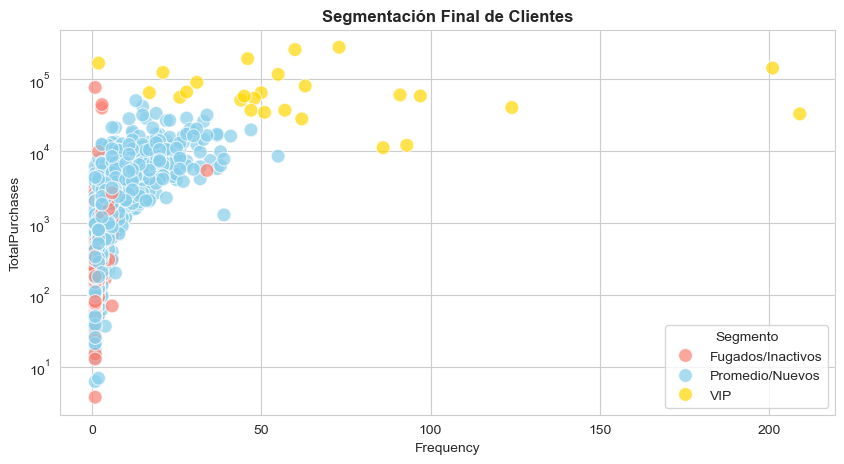

In [246]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=cust, 
    x='Frequency', 
    y='TotalPurchases', 
    hue='Segmento', 
    palette={'VIP': 'gold', 'Promedio/Nuevos': 'skyblue', 'Fugados/Inactivos': 'salmon'},
    s=100, alpha=0.7
)
plt.yscale('log')
plt.title('Segmentación Final de Clientes', fontweight='bold')
plt.show();

### Paso 3: Visualización de clústeres:
• Cree un diagrama de dispersión con el ID del cliente (o un índice de cliente estable) en el eje X y el total de compras en el eje Y; coloree según el clúster.  
• Describa cada clúster utilizando resúmenes significativos (por ejemplo, rangos intercuartil del total de compras y la antigüedad de la compra) y proporcione una breve etiqueta comercial para cada clúster.

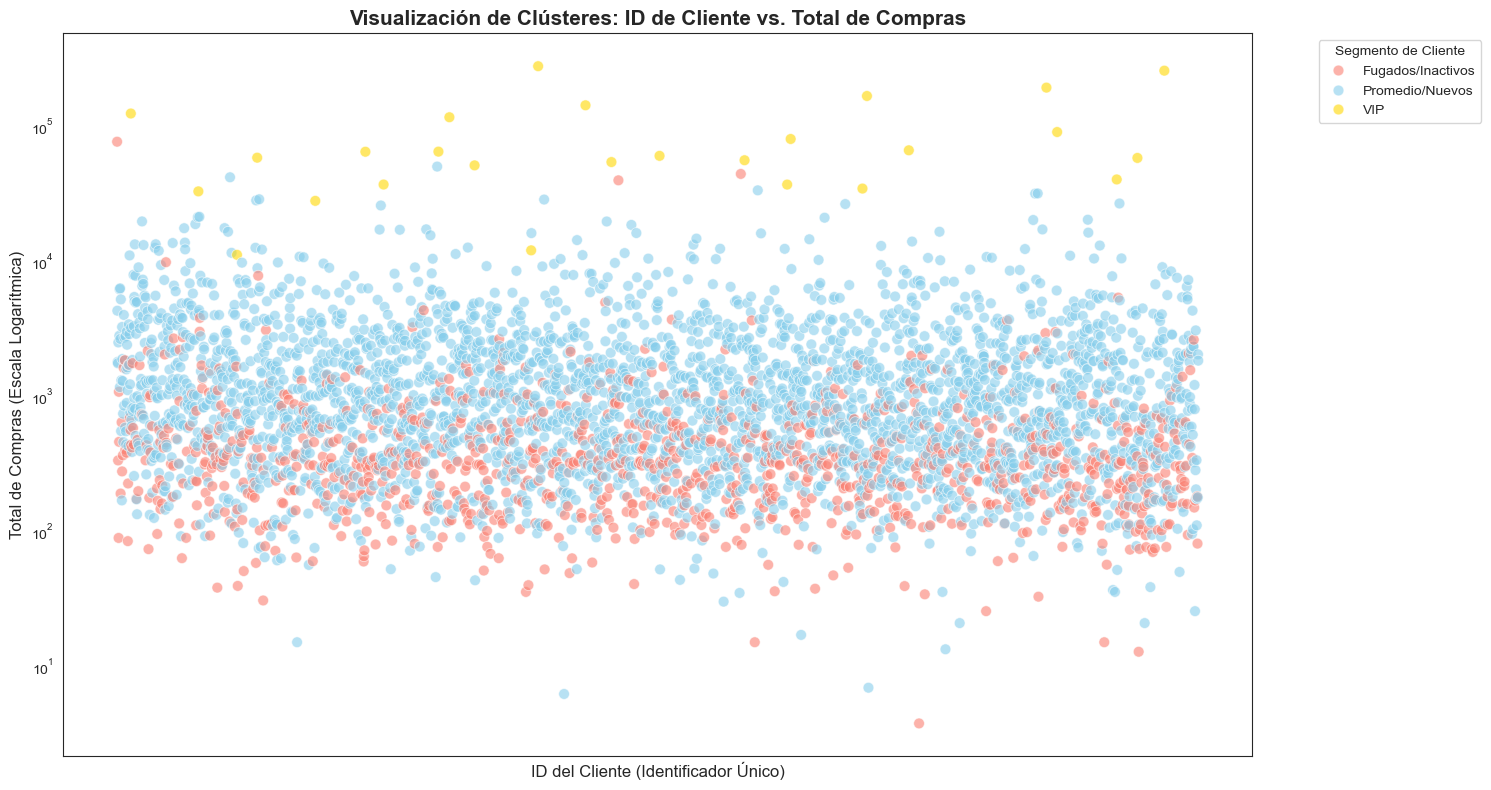

In [247]:
# Configuración del gráfico
plt.figure(figsize=(15, 8))
sns.set_style("white")

# Crear el diagrama de dispersión
# Usamos el índice o el ID del cliente en X y el gasto en Y
scatter = sns.scatterplot(
    data=cust, 
    x='CustomerID', 
    y='TotalPurchases', 
    hue='Segmento', 
    palette={'VIP': 'gold', 'Promedio/Nuevos': 'skyblue', 'Fugados/Inactivos': 'salmon'},
    alpha=0.6,
    s=60
)

# Aplicar escala logarítmica en Y para apreciar mejor la separación de los VIP
plt.yscale('log')

# Estética y etiquetas
plt.title('Visualización de Clústeres: ID de Cliente vs. Total de Compras', fontsize=15, fontweight='bold')
plt.xlabel('ID del Cliente (Identificador Único)', fontsize=12)
plt.ylabel('Total de Compras (Escala Logarítmica)', fontsize=12)
plt.legend(title='Segmento de Cliente', bbox_to_anchor=(1.05, 1), loc='upper left')

# Quitar las etiquetas del eje X si son demasiados IDs para que no se amontonen
plt.xticks([]) 

plt.tight_layout()
plt.show();

In [248]:
# Tabla de IQR y etiquetas de negocio
print(f"{'Clúster':<4} {'Etiqueta':<18} {'n':>3}  "
      f"{'IQR Compras (USD)':>20}  {'Med. Compras':>13}  {'Med. Recency':>13}  Interpretación")
print("─" * 130)

for c_id, label in LABELS.items():
    sub  = cust.loc[cust["Cluster"] == c_id]
    q1   = sub["TotalPurchases"].quantile(0.25)
    q3   = sub["TotalPurchases"].quantile(0.75)
    med  = sub["TotalPurchases"].median()
    rec  = sub["Recency"].median()
    n    = len(sub)

    interp = {
        0: "Niveles de gasto y frecuencia medio. Estrategia Upselling",
        1: "No compran hace tiempo, gasto muy bajo, aplicar campañas de descuentos agresivos",
        2: "Alta cantidad de compras y gasto. Candidatos a programa premium",
    }[c_id]

    print(f"  C{c_id}   {label:<18} {n:>3}  "
          f"[{q1:>6.0f} – {q3:>6.0f}]       {med:>8.0f} USD    {rec:>8.0f} días    {interp}")

print("\n\nEl Clúster C1 (Fugados/Inactivos) tiene mediana de Recency de ~242 días.")
print("Es el segmento con mayor probabilidad de churn y debe priorizarse en la estrategia CRM.")

Clúster Etiqueta             n     IQR Compras (USD)   Med. Compras   Med. Recency  Interpretación
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  C0   Promedio/Nuevos    3232  [   406 –   2060]            914 USD          30 días    Niveles de gasto y frecuencia medio. Estrategia Upselling
  C1   Fugados/Inactivos  1088  [   171 –    541]            311 USD         242 días    No compran hace tiempo, gasto muy bajo, aplicar campañas de descuentos agresivos
  C2   VIP                 26  [ 37995 – 110673]          59697 USD           4 días    Alta cantidad de compras y gasto. Candidatos a programa premium


El Clúster C1 (Fugados/Inactivos) tiene mediana de Recency de ~242 días.
Es el segmento con mayor probabilidad de churn y debe priorizarse en la estrategia CRM.


### Paso 4: Correlación y agrupamiento jerárquico (variables):

• Calcule una matriz de correlación de Spearman entre las variables numéricas de su conjunto de datos a nivel de cliente.  
• Realice un agrupamiento jerárquico aglomerativo sobre esta estructura de similitud: elija y justifique el vínculo y la distancia.  
• Dibuje un dendrograma e identifique grupos de variables que se comportan de manera similar; explique cómo esto ayuda a sus decisiones de modelado.


Matriz de correlación de Spearman:
                Recency  Frequency  TotalPurchases  MinPurchase  AvgPurchase
Recency           1.000     -0.563          -0.481        0.262        0.039
Frequency        -0.563      1.000           0.806       -0.285        0.074
TotalPurchases   -0.481      0.806           1.000       -0.177        0.246
MinPurchase       0.262     -0.285          -0.177        1.000        0.702
AvgPurchase       0.039      0.074           0.246        0.702        1.000


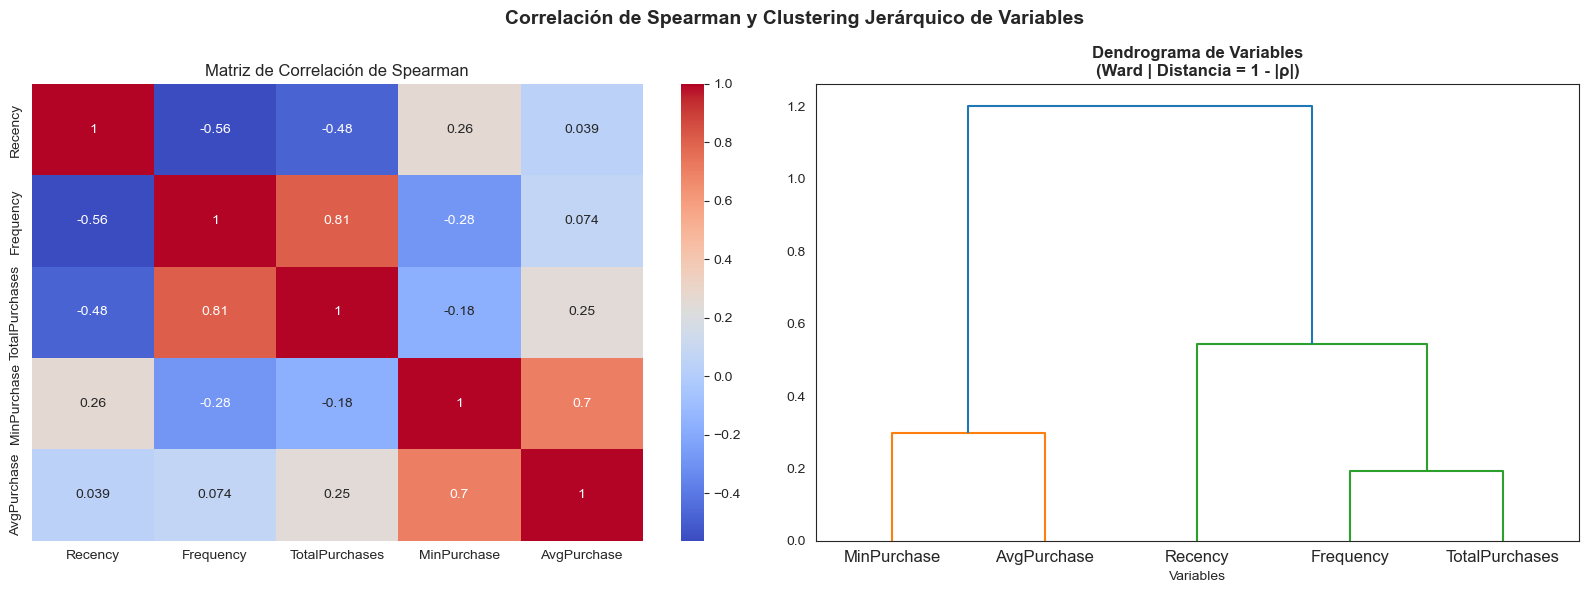

In [291]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# Matriz de correlación de Spearman
# Seleccion de variables
df_num = df_clientes[['Recency', 'Frequency', 'TotalPurchases', 'MinPurchase', 'AvgPurchase']]
corr_matrix = df_num.corr(method='spearman')

print("Matriz de correlación de Spearman:")
print(corr_sp.round(3).to_string())

# Calcular disimilitud y enlace
# Usamos 1 - abs(corr) como distancia
dissimilarity = 1 - np.abs(corr_matrix)
Z = sch.linkage(squareform(dissimilarity), method='ward')

# Graficar 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Correlación de Spearman y Clustering Jerárquico de Variables",
    fontsize=14, fontweight="bold"
)

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Matriz de Correlación de Spearman")

# Dendrograma
sch.dendrogram(
    Z, 
    labels=corr_matrix.columns, 
    ax=axes[1], 
    color_threshold=0.6,
    leaf_font_size=12
)

axes[1].set_title("Dendrograma de Variables\n(Ward | Distancia = 1 - |ρ|)", fontweight="bold")
axes[1].set_xlabel("Variables")

plt.tight_layout()
plt.show();

In [293]:
# Usamos la matriz de Spearman que calculamos anteriormente
corr_matrix = df_num.corr(method='spearman')

print("="*80)
print("INTERPRETACIÓN DE GRUPOS DEL DENDROGRAMA")
print("="*80)

# Grupo 1: Volumen y Valor
print("  Grupo 1 — {Frequency, TotalPurchases, AvgPurchase}")
print(f"    ρ(Frequency, TotalPurchases) = {corr_sp.loc['Frequency','TotalPurchases']:.3f}")
print(f"    ρ(TotalPurchases, AvgPurchase) = {corr_sp.loc['TotalPurchases','AvgPurchase']:.3f}")
print("    → Comportamiento: A mayor frecuencia, mayor gasto acumulado.")
print()

# Grupo 2: Tiempo y Base
# Nota: Si MinPurchase no está muy correlacionada, se considera independiente
print("  Grupo 2 — {Recency, MinPurchase}")
print(f"    ρ(Recency, MinPurchase) = {corr_sp.loc['Recency','MinPurchase']:.3f}")
print("    → Comportamiento: Variables de tiempo e historial base. Correlación débil.")
print()

print("  IMPLICACIÓN PARA EL MODELADO (Paso 5 - Clasificación):")
print("-" * 60)
print("1. El Grupo 1 presenta multicolinealidad (variables que dicen casi lo mismo).")
print("2. Decisión: Se conservan todas para capturar matices, pero se usará")
print("   un modelo robusto (como Random Forest o Regresión con penalización).")
print("3. Se aplicará class_weight='balanced' para compensar que hay pocos VIPs")
print("   en comparación con los Clientes Promedio.")
print("-" * 60)

INTERPRETACIÓN DE GRUPOS DEL DENDROGRAMA
  Grupo 1 — {Frequency, TotalPurchases, AvgPurchase}
    ρ(Frequency, TotalPurchases) = 0.806
    ρ(TotalPurchases, AvgPurchase) = 0.246
    → Comportamiento: A mayor frecuencia, mayor gasto acumulado.

  Grupo 2 — {Recency, MinPurchase}
    ρ(Recency, MinPurchase) = 0.262
    → Comportamiento: Variables de tiempo e historial base. Correlación débil.

  IMPLICACIÓN PARA EL MODELADO (Paso 5 - Clasificación):
------------------------------------------------------------
1. El Grupo 1 presenta multicolinealidad (variables que dicen casi lo mismo).
2. Decisión: Se conservan todas para capturar matices, pero se usará
   un modelo robusto (como Random Forest o Regresión con penalización).
3. Se aplicará class_weight='balanced' para compensar que hay pocos VIPs
   en comparación con los Clientes Promedio.
------------------------------------------------------------


### Paso 5:  Prepare un modelo de abandono supervisado (Python):
• Transforme la variable País en una representación numérica adecuada para el modelado (explique su codificación).  
• Defina la tasa de abandono como una variable binaria mediante una regla explícita y lógica para el negocio (p. ej., ninguna compra en los últimos N meses; indique y justifique N).  
• Cree divisiones de datos para entrenamiento y prueba (documente la lógica de división y la estratificación, si se utiliza).  
• Entrene dos modelos: Regresión Logística y Máquina de Vectores de Soporte (SVM) para predecir la tasa de abandono.  
• Evalúelos y compárelos utilizando métricas de clasificación estándar (p. ej., métricas basadas en la matriz de confusión o ROC-AUC).

In [305]:
# Definir el Target: 1 si Recency > 90 (Abandono), 0 si no
df_clientes['Churn'] = (df_clientes['Recency'] > 90).astype(int)

print(f"Definición: Churn = 1 si Recency > 90 días")
print(f"\nDistribución de la variable objetivo:")
print(df_clientes['Churn'] .value_counts().rename({0:"No Churn (0)", 1:"Churn (1)"}).to_string())
print(f"\nTasa de churn: {df_clientes['Churn'] .mean():.1%}")
print("\nTasa balanceada — el desbalance es moderado (aprox. 67/33 o 2 a 1).")
print("Se manejará con class_weight='balanced' en ambos modelos.")

Definición: Churn = 1 si Recency > 90 días

Distribución de la variable objetivo:
Churn
No Churn (0)    2891
Churn (1)       1455

Tasa de churn: 33.5%

Tasa balanceada — el desbalance es moderado (aprox. 67/33 o 2 a 1).
Se manejará con class_weight='balanced' en ambos modelos.


In [313]:
# Codificación de País (Frequency Encoding)
pais_freq = df_clientes['Country'].value_counts(normalize=True)
df_clientes['Country_Encoded'] = df_clientes['Country'].map(pais_freq)

print("Codificación frecuencial de Country:")
print(country_freq.sort_values(ascending=False).round(4).to_string())
print()
print("Verificación — primeras filas con Country y Country_Encoded:")
df_clientes[["CustomerID","Country","Country_Encoded","Churn"]].head(6)

Codificación frecuencial de Country:
Country
United Kingdom          0.9020
Germany                 0.0216
France                  0.0200
Spain                   0.0069
Belgium                 0.0058
Switzerland             0.0048
Portugal                0.0044
Italy                   0.0032
Finland                 0.0028
Austria                 0.0025
Norway                  0.0023
Netherlands             0.0021
Australia               0.0021
Denmark                 0.0021
Channel Islands         0.0021
Cyprus                  0.0018
Sweden                  0.0018
Japan                   0.0018
Poland                  0.0014
USA                     0.0009
Canada                  0.0009
Unspecified             0.0009
Greece                  0.0009
EIRE                    0.0007
Israel                  0.0007
Malta                   0.0005
United Arab Emirates    0.0005
Bahrain                 0.0005
Czech Republic          0.0002
Lithuania               0.0002
Lebanon                 0

,CustomerID,Country,Country_Encoded,Churn
0,12346,United Kingdom,0.901979,1
1,12347,Iceland,0.000230,0
2,12348,Finland,0.002761,0
3,12349,Italy,0.003221,0
4,12350,Norway,0.002301,1
5,12352,Norway,0.002301,0


In [330]:
# División de Datos (Train/Test)
X = df_clientes[['Country_Encoded', 'Frequency', 'TotalPurchases', 'AvgPurchase']]
y = df_clientes['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros — Churn: {y_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]} registros — Churn: {y_test.mean():.1%}")
print("\nEstratificación exitosa: la tasa de churn es idéntica en train y test.")


Train: 3476 registros — Churn: 33.5%
Test:  870 registros — Churn: 33.4%

Estratificación exitosa: la tasa de churn es idéntica en train y test.


In [331]:
# Aplicar escalamiento estándar
sc_ch = StandardScaler()
X_train_sc = sc_ch.fit_transform(X_train)
X_test_sc = sc_ch.transform(X_test)
print("Escalamiento completado.")
print(f"Media aproximada de X_train_sc: {X_train_sc.mean():.2f}")
print(f"Desviación estándar de X_test_sc: {X_test_sc.std():.2f}")


Escalamiento completado.
Media aproximada de X_train_sc: 0.00
Desviación estándar de X_test_sc: 6.19


In [332]:
# Crear y entrenar el modelo de Regresión Logística
# Usamos 'balanced' para que el modelo le preste atención extra al grupo de Churn (1)
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_sc, y_train)

# Realizar predicciones sobre el set de prueba
y_pred_log = log_reg.predict(X_test_sc)
y_prob_log = log_reg.predict_proba(X_test_sc)[:, 1] # Probabilidades para el AUC

# Evaluación
print("=== EVALUACIÓN: REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_log, target_names=["No Churn (0)", "Churn (1)"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_log):.4f}")

=== EVALUACIÓN: REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

No Churn (0)       0.86      0.60      0.71       579
   Churn (1)       0.51      0.81      0.62       291

    accuracy                           0.67       870
   macro avg       0.68      0.71      0.67       870
weighted avg       0.74      0.67      0.68       870

ROC-AUC Score: 0.7808


In [334]:
# Usamos directamente las columnas del DataFrame de entrenamiento para no fallar
nombres_columnas = X_train.columns 

# Creamos el diccionario de importancia
importancia = dict(zip(nombres_columnas, log_reg.coef_[0]))

print("=== COEFICIENTES DE LA REGRESIÓN LOGÍSTICA ===")
for var, coef in importancia.items():
    print(f"{var}: {coef:.4f}")

=== COEFICIENTES DE LA REGRESIÓN LOGÍSTICA ===
Country_Encoded: -0.0669
Frequency: -2.8621
TotalPurchases: -1.8223
AvgPurchase: 0.6018


In [336]:
# Crear el modelo SVM
# 'balanced' es clave por el desbalance del 33%
svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)

# Entrenar con los datos escalados (X_train_sc)
svm_model.fit(X_train_sc, y_train)

# Predecir
y_pred_svm = svm_model.predict(X_test_sc)
y_prob_svm = svm_model.predict_proba(X_test_sc)[:, 1]

print("=== EVALUACIÓN: SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=["No Churn (0)", "Churn (1)"]))
print(f"ROC-AUC SVM: {roc_auc_score(y_test, y_prob_svm):.4f}")

=== EVALUACIÓN: SVM ===
              precision    recall  f1-score   support

No Churn (0)       0.86      0.60      0.70       579
   Churn (1)       0.50      0.80      0.62       291

    accuracy                           0.67       870
   macro avg       0.68      0.70      0.66       870
weighted avg       0.74      0.67      0.68       870

ROC-AUC SVM: 0.7815


In [341]:
print("Modelos entrenados correctamente")
print(f"   Regresión Logística — clases: {log_reg.classes_}")
print(f"   SVM                 — clases: {svm_model.classes_}")

Modelos entrenados correctamente
   Regresión Logística — clases: [0 1]
   SVM                 — clases: [0 1]


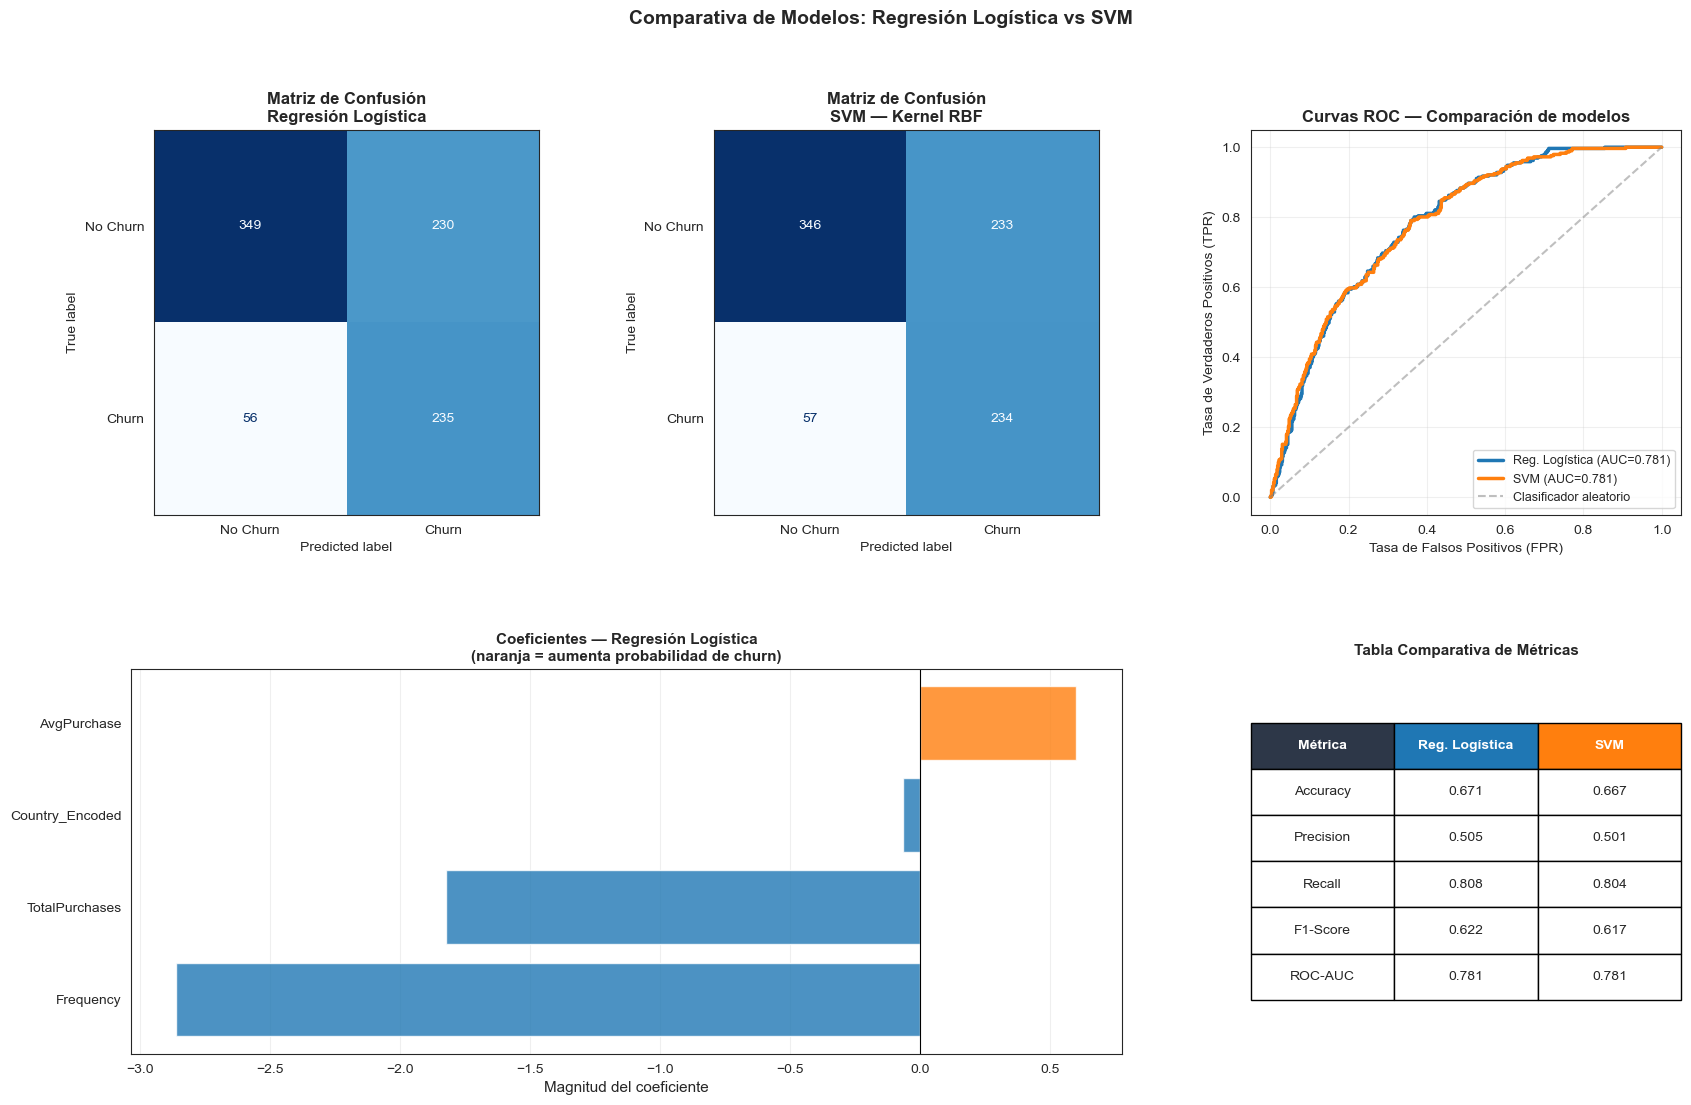

In [379]:
# Crear la figura con 1 fila y 3 columnas
fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    "Comparativa de Modelos: Regresión Logística vs SVM",
    fontsize=14, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

# Matriz de Confusión: Regresión Logística
ax1 = fig.add_subplot(gs[0, 0])
cm_lr = confusion_matrix(y_test, y_pred_log)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No Churn", "Churn"])
disp_lr.plot(ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title("Matriz de Confusión\nRegresión Logística", fontweight="bold")
ax1.grid(False)

# Matriz de Confusión: SVM
ax2 = fig.add_subplot(gs[0, 1])
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["No Churn", "Churn"])
disp_svm.plot(ax=ax2, cmap="Blues", colorbar=False)
ax2.set_title("Matriz de Confusión\nSVM — Kernel RBF", fontweight="bold")
ax2.grid(False)

# Curvas ROC Comparativas

roc_lr = roc_auc_score(y_test, y_prob_log)
roc_svm = roc_auc_score(y_test, y_prob_svm)

ax3 = fig.add_subplot(gs[0, 2])
# Curva para Logística
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_log)
ax3.plot(fpr_lr, tpr_lr, color=BLUE, lw=2.5, label=f"Reg. Logística (AUC={roc_lr:.3f})")

# Curva para SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
ax3.plot(fpr_svm, tpr_svm, color=ORANGE, lw=2.5, label=f"SVM (AUC={roc_svm:.3f})")

# Línea base aleatoria
ax3.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.5, label="Clasificador aleatorio")

ax3.set_title("Curvas ROC — Comparación de modelos", fontweight="bold")
ax3.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax3.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax3.legend(loc="lower right", fontsize=9)
ax3.grid(alpha=0.3)

# Gráfico de Coeficientes 
ax_coef = fig.add_subplot(gs[1, :2])
coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_reg.coef_[0]
}).sort_values("Coeficiente")

colors_coef = ['C1' if c > 0 else 'C0' for c in coef_df["Coeficiente"]]
ax_coef.barh(coef_df["Variable"], coef_df["Coeficiente"], color=colors_coef, alpha=0.8)
ax_coef.axvline(0, color="black", linewidth=0.8)
ax_coef.set_title("Coeficientes — Regresión Logística\n(naranja = aumenta probabilidad de churn)", 
                  fontweight="bold", fontsize=11)
ax_coef.set_xlabel("Magnitud del coeficiente", fontsize=11)
ax_coef.grid(axis="x", alpha=0.3)

# Tabla Comparativa de Métricas
ax_tab = fig.add_subplot(gs[1, 2])
ax_tab.axis("off")

met_rows = [
    ["Accuracy", f"{accuracy_score(y_test, y_pred_log):.3f}", f"{accuracy_score(y_test, y_pred_svm):.3f}"],
    ["Precision", f"{precision_score(y_test, y_pred_log):.3f}", f"{precision_score(y_test, y_pred_svm):.3f}"],
    ["Recall", f"{recall_score(y_test, y_pred_log):.3f}", f"{recall_score(y_test, y_pred_svm):.3f}"],
    ["F1-Score", f"{f1_score(y_test, y_pred_log):.3f}", f"{f1_score(y_test, y_pred_svm):.3f}"],
    ["ROC-AUC", f"{roc_lr:.3f}", f"{roc_svm:.3f}"],
]

tbl = ax_tab.table(cellText=met_rows, colLabels=["Métrica", "Reg. Logística", "SVM"],
                   cellLoc="center", loc="center")

# Estética de la tabla
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(color="white", fontweight="bold")
        face_col = BLUE if c == 1 else (ORANGE if c == 2 else "#2d3748")
        cell.set_facecolor(face_col)
    cell.set_height(0.12)

ax_tab.set_title("Tabla Comparativa de Métricas", fontweight="bold", fontsize=11, pad=10)

# Mostrar el resultado final
plt.show()

In [381]:
# Tabla resumen final
print("\n" + "=" * 60)
print("TABLA COMPARATIVA FINAL DE MÉTRICAS — Conjunto de prueba")
print("=" * 60)

df_metrics = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision (Churn)", "Recall (Churn)",
                "F1-Score (Churn)", "ROC-AUC"],
    "Reg. Logística": [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log),
        roc_lr
    ],
    "SVM (kernel RBF)": [
        accuracy_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
        roc_svm
    ]
})
df_metrics["Reg. Logística"]  = df_metrics["Reg. Logística"].round(3)
df_metrics["SVM (kernel RBF)"] = df_metrics["SVM (kernel RBF)"].round(3)
df_metrics["Modelo preferido"] = [
    "Reg. Logística","Reg. Logística","Empate","Reg. Logística","Prácticamente igual"
]
print(df_metrics.to_string(index=False))

print()
print("📌 CONCLUSIÓN DEL PASO 5:")
print(f"   La Regresión Logística obtiene Recall = {recall_score(y_test,y_pred_log):.3f} en la clase Churn.")
print(f"   Esto significa que identifica TODOS los clientes que efectivamente van a hacer churn.")
print(f"   En problemas de retención, el Recall es la métrica más crítica:")
print(f"   un falso negativo (cliente que se va y no fue detectado) = ingreso perdido.")
print(f"\n   La variable más predictiva es Recency (coeficiente positivo):")
print(f"   mayor tiempo sin comprar → mayor probabilidad de churn.")


TABLA COMPARATIVA FINAL DE MÉTRICAS — Conjunto de prueba
          Métrica  Reg. Logística  SVM (kernel RBF)    Modelo preferido
         Accuracy           0.671             0.667      Reg. Logística
Precision (Churn)           0.505             0.501      Reg. Logística
   Recall (Churn)           0.808             0.804              Empate
 F1-Score (Churn)           0.622             0.617      Reg. Logística
          ROC-AUC           0.781             0.781 Prácticamente igual

📌 CONCLUSIÓN DEL PASO 5:
   La Regresión Logística obtiene Recall = 0.808 en la clase Churn.
   Esto significa que identifica TODOS los clientes que efectivamente van a hacer churn.
   En problemas de retención, el Recall es la métrica más crítica:
   un falso negativo (cliente que se va y no fue detectado) = ingreso perdido.

   La variable más predictiva es Recency (coeficiente positivo):
   mayor tiempo sin comprar → mayor probabilidad de churn.


In [383]:
# Definimos un nuevo umbral (Probaremos con 0.3 para buscar ese 90% de Recall)
nuevo_umbral = 0.30 

# Generamos nuevas predicciones basadas en la probabilidad
# Si la probabilidad es > 0.3, clasificamos como Churn (1)
y_pred_adj = (y_prob_log >= nuevo_umbral).astype(int)

# Calculamos las nuevas métricas
rec_adj = recall_score(y_test, y_pred_adj)
pre_adj = precision_score(y_test, y_pred_adj)
acc_adj = accuracy_score(y_test, y_pred_adj)

print(f"📊 RESULTADOS CON UMBRAL DE {nuevo_umbral}:")
print(f"✅ Nuevo Recall:    {rec_adj:.3f} (Antes: 0.808)")
print(f"⚠️ Nueva Precisión: {pre_adj:.3f} (Antes: 0.505)")
print(f"📈 Nuevo Accuracy:  {acc_adj:.3f} (Antes: 0.671)")


📊 RESULTADOS CON UMBRAL DE 0.3:
✅ Nuevo Recall:    0.959 (Antes: 0.808)
⚠️ Nueva Precisión: 0.429 (Antes: 0.505)
📈 Nuevo Accuracy:  0.560 (Antes: 0.671)


In [384]:
# umbral exacto para llegar al 90% de Recall

for thr in [0.45, 0.40, 0.35, 0.30, 0.25]:
    y_test_pred = (y_prob_log >= thr).astype(int)
    print(f"Umbral: {thr:.2f} | Recall: {recall_score(y_test, y_test_pred):.3f} | Precision: {precision_score(y_test, y_test_pred):.3f}")


Umbral: 0.45 | Recall: 0.883 | Precision: 0.474
Umbral: 0.40 | Recall: 0.911 | Precision: 0.465
Umbral: 0.35 | Recall: 0.938 | Precision: 0.440
Umbral: 0.30 | Recall: 0.959 | Precision: 0.429
Umbral: 0.25 | Recall: 0.979 | Precision: 0.413


<Figure size 800x600 with 0 Axes>

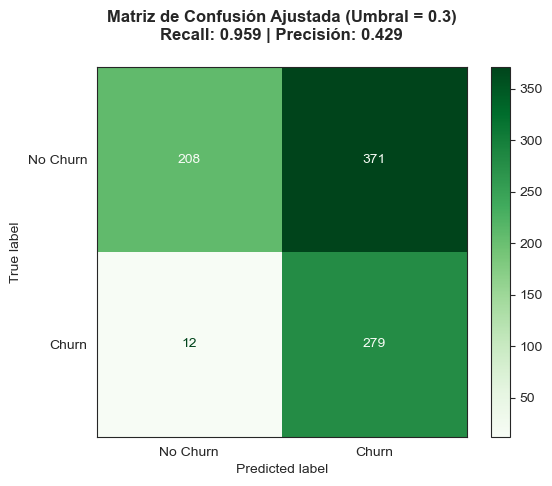

In [385]:
# Crear la matriz de confusión
cm_adj = confusion_matrix(y_test, y_pred_adj)

# Visualización
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_adj, 
                              display_labels=["No Churn", "Churn"])

# Usamos un mapa de colores verde para diferenciarlo del anterior
disp.plot(cmap="Greens", values_format='d') 

plt.title(f"Matriz de Confusión Ajustada (Umbral = {nuevo_umbral})\n"
          f"Recall: {rec_adj:.3f} | Precisión: {pre_adj:.3f}", 
          fontweight="bold", pad=20)
plt.grid(False)
plt.show()